In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2

from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score

In [2]:
iris = load_iris()

len(iris['target'])  # 150 samples

150

In [3]:
def load_images_from_folder(folder_path, label, image_size=(64, 64)):
    imgs = []
    targets = []

    for fname in os.listdir(folder_path):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue  # 허용된 이미지 확장자만
        path = os.path.join(folder_path, fname)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"❌ 이미지 로딩 실패: {path}")
            continue
        try:
            img = cv2.resize(img, image_size)
        except Exception as e:
            print(f"⚠️ 이미지 리사이즈 실패: {path} - {e}")
            continue
        flat_vector = img.flatten() / 255.0
        imgs.append(flat_vector)
        targets.append(label)
    
    print(f"✅ {folder_path}에서 로드된 이미지 수: {len(imgs)}")
    return imgs, targets

# 각 클래스 로드
cat_imgs, cat_targets = load_images_from_folder("data/cats2", label=0)
dog_imgs, dog_targets = load_images_from_folder("data/dogs2", label=1)

# 합치기
all_imgs = cat_imgs + dog_imgs
all_targets = cat_targets + dog_targets

# numpy 배열 변환
cat_dog_dataset = {
    'data': np.array(all_imgs),
    'target': np.array(all_targets)
}

print("🎉 전체 이미지 수:", len(cat_dog_dataset['data']))

✅ data/cats2에서 로드된 이미지 수: 600
✅ data/dogs2에서 로드된 이미지 수: 600
🎉 전체 이미지 수: 1200


In [8]:
class Perceptron:
    def __init__(self, lr=0.1, epochs=10):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        self.w = np.zeros(X.shape[1])
        self.b = 0

        # print("🔧 초기 가중치:", self.w, "바이어스:", self.b)

        total_errors = []

        for epoch in range(self.epochs):
            # print(f"\n📘 [Epoch {epoch+1}]")
            errors = 0
            for i, (xi, target) in enumerate(zip(X, y)):
                z = np.dot(xi, self.w) + self.b
                y_pred = 1 if z >= 0 else 0
                error = target - y_pred

                self.w += self.lr * error * xi
                self.b += self.lr * error

                if error != 0:
                    errors += 1

                # 디버깅 출력
                # print(f"  샘플 {i+1}: 입력={xi}, 실제={target}, 예측={y_pred}, 오차={error}")
                # print(f"    가중치 → {self.w}")
                # print(f"    바이어스 → {self.b}")

            total_errors.append(errors)
        return total_errors


    def predict(self, X):
        X = np.array(X)
        z = np.dot(X, self.w) + self.b  # 모든 샘플에 대해 z 계산 (벡터 연산)
        return np.where(z >= 0, 1, 0)   # 조건에 따라 1 또는 0 반환

In [9]:
X = cat_dog_dataset['data']
y = cat_dog_dataset['target']

epochs = 10
model = Perceptron(lr=0.1, epochs=epochs)
errors = model.fit(X, y)

y_pred = model.predict(X)
y_true = y

print("📊 최종 예측 결과:", y_pred)
acc = accuracy_score(y_true, y_pred)
print(f"🎯 정확도: {acc:.2f}")

📊 최종 예측 결과: [0 1 1 ... 1 1 1]
🎯 정확도: 0.50


In [ ]:
plt.plot(range(1, epochs + 1), errors, marker='o')
plt.title("Perceptron: Epoch vs Misclassifications")
plt.xlabel("Epoch")
plt.ylabel("Number of errors")
plt.grid(True)
plt.show()

In [ ]:
imgs = []
target = [0,0,1,1,1]

for i in range(1, 5+1):
    img = cv2.imread(f"data/ex/{i}.png", cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    img = cv2.resize(img, (64, 64))
    flat_vector = img.flatten() / 255.0
    imgs.append(flat_vector)
print("✅ 불러온 이미지 수:", len(imgs))

X = cat_dog_dataset['data']
y = cat_dog_dataset['target']
y_pred = model.predict(X)
y_true = y


X = np.array(imgs)
y = np.array(target)

y_pred = model.predict(X)
y_true = y

print("📊 최종 예측 결과:", y_pred)
acc = accuracy_score(y_true, y_pred)
print(f"🎯 정확도: {acc:.2f}")


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
import pickle

📊 예측 결과: [1 1 0 0 0 1 0 1 0 0 1 1 0 1 0 0 1 0 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 0
 1 1 0 0 1 1 1 0 0 1 0 1 1 1 1 1 0 0 1 1 1 1 0 0 1 1 0 1 1 0 0 1 1 0 0 1 1
 1 0 0 0 1 0 0 1 1 1 0 0 0 0 1 0 0 1 0 0 1 0 1 1 0 1 1 0 1 0 1 1 0 0 1 1 0
 1 1 1 1 1 1 1 0 0 1 0 1 0 1 1 0 0 1 1 0 1 0 0 1 0 0 1 1 1 0 0 0 1 1 0 1 1
 0 1 0 0 0 0 0 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 1 1 1 1 1 0 1 1
 0 1 1 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 1 1 0 1 0 0 1 1 0 0 0 0 1 1 1 1 1 1 1
 0 0 0 0 1 0 1 1 0 0 1 1 0 0 1 1 0 0]
🎯 정확도: 0.57


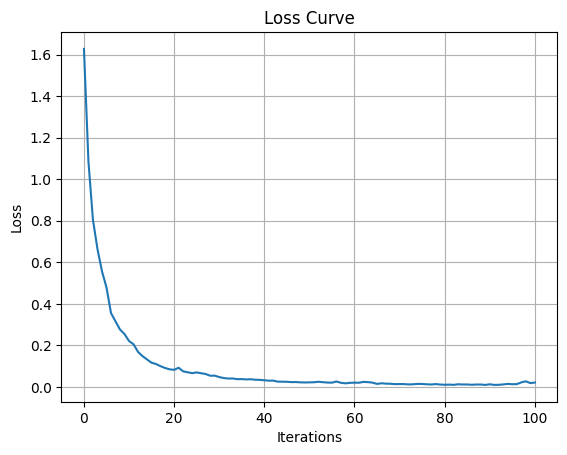

In [14]:
X = cat_dog_dataset['data']
y = cat_dog_dataset['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("📊 예측 결과:", y_pred)
print(f"🎯 정확도: {acc:.2f}")

with open('models/cat_dog_model.pickle', 'wb') as f:
    pickle.dump(mlp, f)

plt.plot(mlp.loss_curve_)
plt.title("Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.grid(True)
plt.show()